# Credit Risk – Model Training, Tuning & Evaluation


In [2]:
# ==== Imports ====
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

DATA_DIR = Path("/content/")
TRAIN_PATH = DATA_DIR / "processed_train.csv"
TEST_PATH  = DATA_DIR / "processed_test.csv"


## 1) Train/Test Split


In [3]:
df_train_full = pd.read_csv(TRAIN_PATH)
print("Shape:", df_train_full.shape)
display(df_train_full.head())

TARGET = "SeriousDlqin2yrs"
DROP_COLS = ["Id", TARGET]

print("\nTarget distribution:")
print(df_train_full[TARGET].value_counts(normalize=True).rename("ratio"))


Shape: (145698, 13)


,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyDebt,NonRealEstateLoans
0,1,1,0.766127,45.0,2,9120.0,13.0,0,6.0,0,2.0,7323.197016,7.0
1,2,0,0.957151,40.0,0,2600.0,4.0,0,0.0,0,1.0,316.878123,4.0
2,3,0,0.658180,38.0,1,3042.0,2.0,1,0.0,0,0.0,258.914887,2.0
3,4,0,0.233810,30.0,0,3300.0,5.0,0,0.0,0,0.0,118.963951,5.0
4,5,0,0.907239,49.0,1,63588.0,7.0,0,1.0,0,0.0,1584.975094,6.0



Target distribution:
SeriousDlqin2yrs
0    0.940727
1    0.059273
Name: ratio, dtype: float64


In [5]:
X = df_train_full.drop(columns=DROP_COLS)
y = df_train_full[TARGET]

FEATURE_NAMES = X.columns.tolist()
print("Features:", FEATURE_NAMES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)




Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyDebt', 'NonRealEstateLoans']


## 2) (Evaluation + Plotting)


In [10]:
results_store = {}
fitted_models  = {}

def evaluate_model(name, model, X_te, y_te, threshold=0.5, verbose=True):

    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, y_proba),
    }

    if verbose:
        print(f"===== {name} — Quick Evaluation =====")
        for k, v in metrics.items():
            if k != "model":
                print(f"{k:>10}: {v:.4f}")
        print("\nClassification report:")
        print(classification_report(y_te, y_pred, digits=3, zero_division=0))

        cm = confusion_matrix(y_te, y_pred)
        fig, ax = plt.subplots(figsize=(4, 3.5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"], ax=ax)
        ax.set_title(f"{name} — Confusion Matrix")
        plt.tight_layout()
        plt.show()

    return metrics, y_proba


## 3) Model 1 — Logistic Regression

### Baseline

===== Logistic Regression (baseline) — Quick Evaluation =====
  accuracy: 0.7955
 precision: 0.1890
    recall: 0.7446
        f1: 0.3015
   roc_auc: 0.8540

Classification report:
              precision    recall  f1-score   support

           0      0.980     0.799     0.880     27413
           1      0.189     0.745     0.301      1727

    accuracy                          0.795     29140
   macro avg      0.585     0.772     0.591     29140
weighted avg      0.933     0.795     0.846     29140



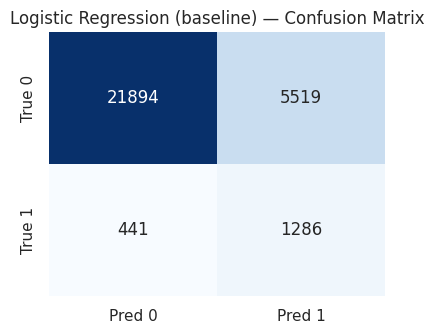

In [11]:
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

logreg_pipe.fit(X_train, y_train)
baseline_metrics_lr, _ = evaluate_model("Logistic Regression (baseline)", logreg_pipe, X_test, y_test)


### Hyperparameter Tuning — Logistic Regression



In [8]:
param_dist_lr = {
    "clf__C": np.logspace(-3, 2, 20),
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear", "saga"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search_lr = RandomizedSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    param_distributions=param_dist_lr,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

search_lr.fit(X_train, y_train)
print("Best params (LR):", search_lr.best_params_)
print("Best CV ROC-AUC (LR):", round(search_lr.best_score_, 4))

best_logreg = search_lr.best_estimator_


Best params (LR): {'clf__solver': 'liblinear', 'clf__penalty': 'l2', 'clf__C': np.float64(0.003359818286283781)}
Best CV ROC-AUC (LR): 0.8426


### Evaluation — Logistic Regression (Tuned)

===== Logistic Regression — Quick Evaluation =====
  accuracy: 0.7947
 precision: 0.1886
    recall: 0.7464
        f1: 0.3011
   roc_auc: 0.8540

Classification report:
              precision    recall  f1-score   support

           0      0.980     0.798     0.880     27413
           1      0.189     0.746     0.301      1727

    accuracy                          0.795     29140
   macro avg      0.584     0.772     0.590     29140
weighted avg      0.933     0.795     0.845     29140



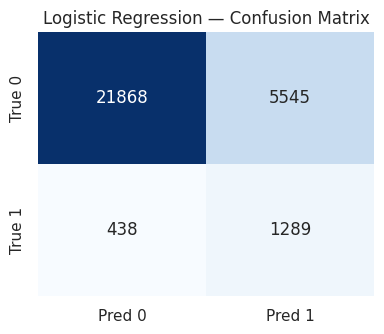

In [12]:
lr_metrics, lr_proba = evaluate_model("Logistic Regression", best_logreg, X_test, y_test)
results_store["Logistic Regression"] = lr_metrics
fitted_models["Logistic Regression"] = best_logreg


## 4) Model 2 — LightGBM

### Baseline

===== LightGBM (baseline) — Quick Evaluation =====
  accuracy: 0.8127
 precision: 0.2042
    recall: 0.7458
        f1: 0.3206
   roc_auc: 0.8574

Classification report:
              precision    recall  f1-score   support

           0      0.981     0.817     0.891     27413
           1      0.204     0.746     0.321      1727

    accuracy                          0.813     29140
   macro avg      0.592     0.781     0.606     29140
weighted avg      0.935     0.813     0.858     29140



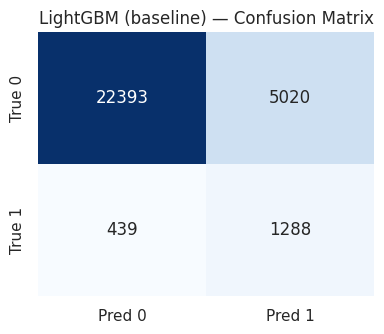

In [13]:
lgbm_baseline = LGBMClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_estimators=200,
    verbose=-1,
)
lgbm_baseline.fit(X_train, y_train)
baseline_metrics_lgbm, _ = evaluate_model("LightGBM (baseline)", lgbm_baseline, X_test, y_test)


### Hyperparameter Tuning — LightGBM

In [14]:
param_dist_lgbm = {
    "n_estimators": [100, 200, 300, 500],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1, 5],
    "reg_lambda": [0, 0.1, 1, 5],
}

search_lgbm = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=RANDOM_STATE, class_weight="balanced", verbose=-1),
    param_distributions=param_dist_lgbm,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

search_lgbm.fit(X_train, y_train)
print("Best params (LightGBM):", search_lgbm.best_params_)
print("Best CV ROC-AUC (LightGBM):", round(search_lgbm.best_score_, 4))

best_lgbm = search_lgbm.best_estimator_


Best params (LightGBM): {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 100, 'min_child_samples': 50, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV ROC-AUC (LightGBM): 0.8521


### Evaluation — LightGBM (Tuned)

===== LightGBM — Quick Evaluation =====
  accuracy: 0.7852
 precision: 0.1880
    recall: 0.7904
        f1: 0.3037
   roc_auc: 0.8638

Classification report:
              precision    recall  f1-score   support

           0      0.983     0.785     0.873     27413
           1      0.188     0.790     0.304      1727

    accuracy                          0.785     29140
   macro avg      0.586     0.788     0.588     29140
weighted avg      0.936     0.785     0.839     29140



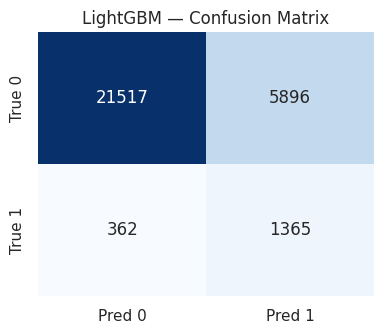

In [15]:
lgbm_metrics, lgbm_proba = evaluate_model("LightGBM", best_lgbm, X_test, y_test)
results_store["LightGBM"] = lgbm_metrics
fitted_models["LightGBM"] = best_lgbm


## 5) Model 3 — XGBoost

### Baseline

===== XGBoost (baseline) — Quick Evaluation =====
  accuracy: 0.8463
 precision: 0.2170
    recall: 0.6109
        f1: 0.3202
   roc_auc: 0.8161

Classification report:
              precision    recall  f1-score   support

           0      0.972     0.861     0.913     27413
           1      0.217     0.611     0.320      1727

    accuracy                          0.846     29140
   macro avg      0.595     0.736     0.617     29140
weighted avg      0.928     0.846     0.878     29140



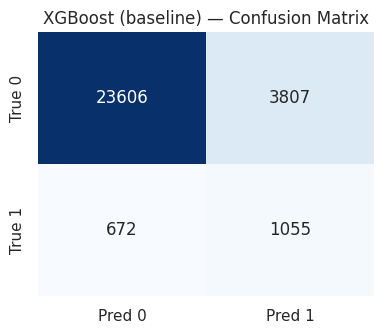

In [16]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_baseline = XGBClassifier(
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    eval_metric="auc",
    use_label_encoder=False,
)
xgb_baseline.fit(X_train, y_train)
baseline_metrics_xgb, _ = evaluate_model("XGBoost (baseline)", xgb_baseline, X_test, y_test)


### Hyperparameter Tuning — XGBoost

In [17]:
param_dist_xgb = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.5, 1],
    "reg_alpha": [0, 0.1, 1, 5],
    "reg_lambda": [0.5, 1, 2, 5],
    "scale_pos_weight": [1, scale_pos_weight / 2, scale_pos_weight],
}

search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE, eval_metric="auc", use_label_encoder=False),
    param_distributions=param_dist_xgb,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

search_xgb.fit(X_train, y_train)
print("Best params (XGBoost):", search_xgb.best_params_)
print("Best CV ROC-AUC (XGBoost):", round(search_xgb.best_score_, 4))

best_xgb = search_xgb.best_estimator_


Best params (XGBoost): {'subsample': 0.6, 'scale_pos_weight': 1, 'reg_lambda': 0.5, 'reg_alpha': 5, 'n_estimators': 200, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.6}
Best CV ROC-AUC (XGBoost): 0.8529


### Evaluation — XGBoost (Tuned)

===== XGBoost — Quick Evaluation =====
  accuracy: 0.9433
 precision: 0.5931
    recall: 0.1384
        f1: 0.2244
   roc_auc: 0.8651

Classification report:
              precision    recall  f1-score   support

           0      0.948     0.994     0.971     27413
           1      0.593     0.138     0.224      1727

    accuracy                          0.943     29140
   macro avg      0.771     0.566     0.597     29140
weighted avg      0.927     0.943     0.926     29140



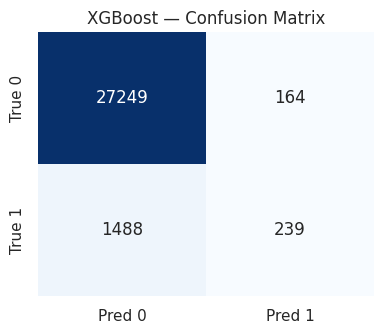

In [18]:
xgb_metrics, xgb_proba = evaluate_model("XGBoost", best_xgb, X_test, y_test)
results_store["XGBoost"] = xgb_metrics
fitted_models["XGBoost"] = best_xgb


## 6) Full Evaluation & Comparison



In [19]:
comparison_df = pd.DataFrame([
    results_store["Logistic Regression"],
    results_store["LightGBM"],
    results_store["XGBoost"],
]).set_index("model").round(4)

comparison_df = comparison_df.sort_values("roc_auc", ascending=False)
comparison_df


,accuracy,precision,recall,f1,roc_auc
model,,,,,
XGBoost,0.9433,0.5931,0.1384,0.2244,0.8651
LightGBM,0.7852,0.1880,0.7904,0.3037,0.8638
Logistic Regression,0.7947,0.1886,0.7464,0.3011,0.8540


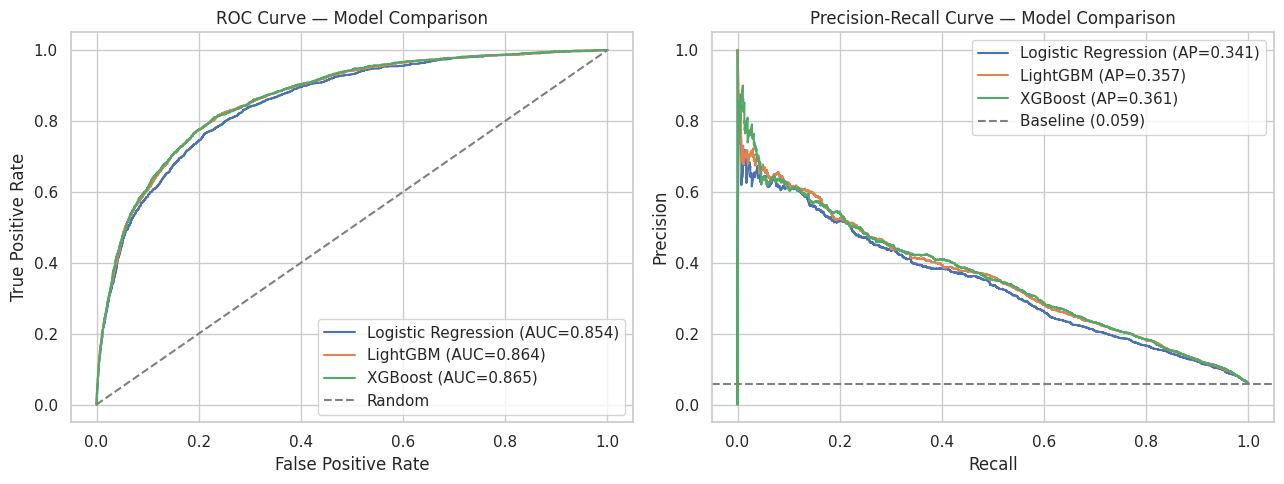

In [31]:
#  ROC curves overlay
proba_map = {
    "Logistic Regression": lr_proba,
    "LightGBM": lgbm_proba,
    "XGBoost": xgb_proba,
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba in proba_map.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = results_store[name]["roc_auc"]
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Model Comparison")
axes[0].legend(loc="lower right")

for name, proba in proba_map.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})")

baseline_rate = y_test.mean()
axes[1].axhline(baseline_rate, linestyle="--", color="grey", label=f"Baseline ({baseline_rate:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — Model Comparison")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


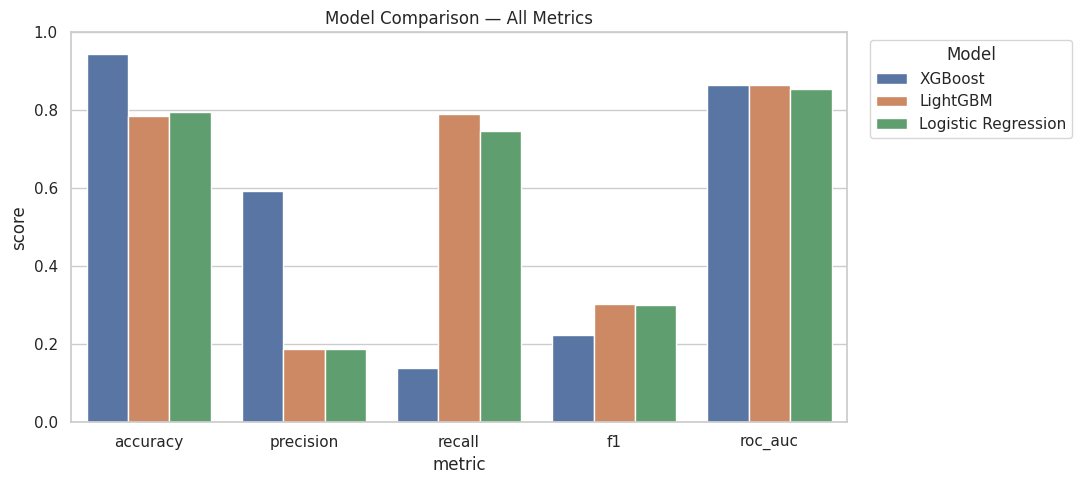

In [24]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]
plot_df = comparison_df[metrics_to_plot].reset_index().melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model")
plt.title("Model Comparison — All Metrics")
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


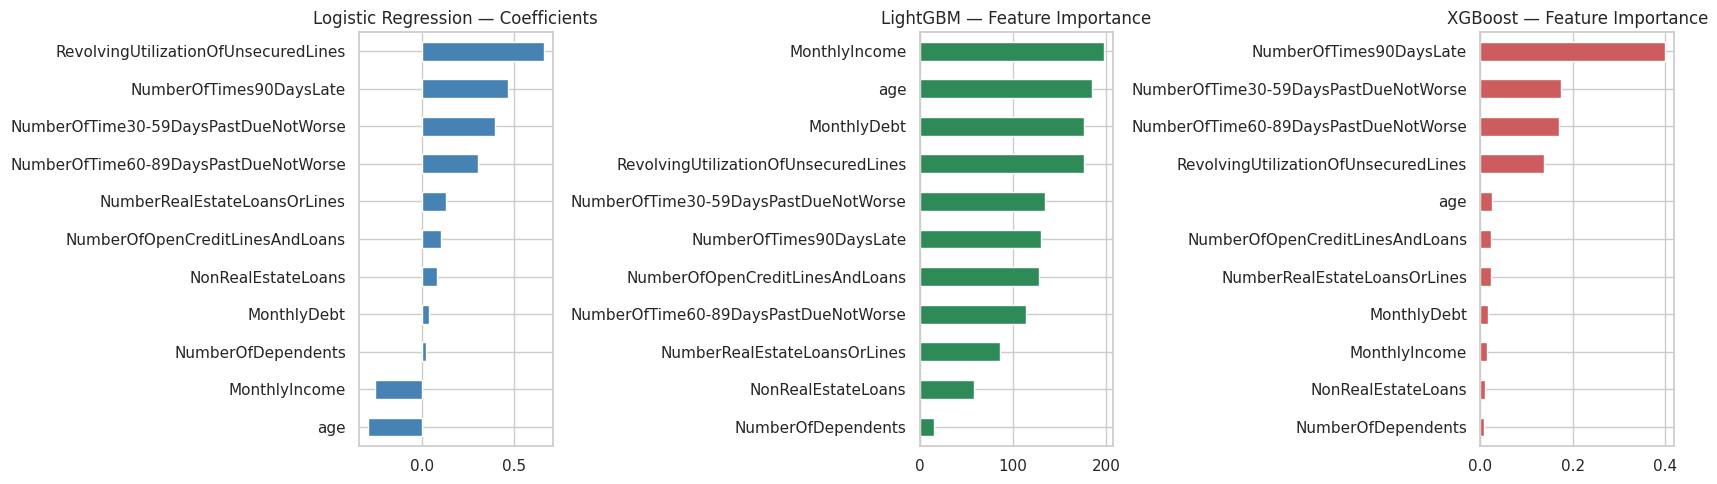

In [25]:
#  Feature importance
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

lr_coef = pd.Series(best_logreg.named_steps["clf"].coef_[0], index=FEATURE_NAMES).sort_values()
lr_coef.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Logistic Regression — Coefficients")

lgbm_imp = pd.Series(best_lgbm.feature_importances_, index=FEATURE_NAMES).sort_values()
lgbm_imp.plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("LightGBM — Feature Importance")

xgb_imp = pd.Series(best_xgb.feature_importances_, index=FEATURE_NAMES).sort_values()
xgb_imp.plot(kind="barh", ax=axes[2], color="indianred")
axes[2].set_title("XGBoost — Feature Importance")

plt.tight_layout()
plt.show()


### save the best model

In [26]:
best_model_name = comparison_df["roc_auc"].idxmax()
best_model = fitted_models[best_model_name]
best_row = comparison_df.loc[best_model_name]

joblib.dump(best_model,  "best_model.pkl")
comparison_df.to_csv( "model_comparison.csv")
print(f"\nBest model ('{best_model_name}') saved to: { 'best_model.pkl'}")



Best model ('XGBoost') saved to: best_model.pkl


In [30]:
joblib.dump(best_model, "best_model.joblib")
print("Best model saved to: best_model.joblib")

Best model saved to: best_model.joblib


## 7) Final Test



In [28]:
df_test_real = pd.read_csv(TEST_PATH)
X_test_real = df_test_real.drop(columns=[c for c in DROP_COLS if c in df_test_real.columns])

assert list(X_test_real.columns) == FEATURE_NAMES

#  sanity checks
sample_pred = best_model.predict_proba(X_test_real.head(5))[:, 1]
assert sample_pred.shape[0] == 5
assert np.all((sample_pred >= 0) & (sample_pred <= 1))
print("Sanity check OK — sample predicted probabilities:", np.round(sample_pred, 4))

# test set
test_proba = best_model.predict_proba(X_test_real)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

assert not np.isnan(test_proba).any()
assert test_proba.shape[0] == df_test_real.shape[0]

submission = pd.DataFrame({
    "Id": df_test_real["Id"],
    "predicted_probability": test_proba,
    "predicted_class": test_pred,
})

print(f"\nBest model used: {best_model_name}")
print("Predicted default rate on real test set:", round(submission['predicted_class'].mean(), 4))
display(submission.head(10))

submission_path = "test_predictions.csv"
submission.to_csv(submission_path, index=False)
print(f"\n Submission file saved to: {submission_path}")

Sanity check OK — sample predicted probabilities: [0.0655 0.0429 0.0119 0.0778 0.0968]

Best model used: XGBoost
Predicted default rate on real test set: 0.0186


,Id,predicted_probability,predicted_class
0,1,0.065451,0
1,2,0.042886,0
2,3,0.011937,0
3,4,0.077796,0
4,5,0.096759,0
5,6,0.030267,0
6,7,0.045493,0
7,8,0.037456,0
8,9,0.004923,0
9,10,0.534416,1



 Submission file saved to: test_predictions.csv
